# RAG - Retriveal Augmented Generation 


*First lets understand how RAG came in picture.*

Large language Models(LLMs) have changed how we interact with information. They can write summarize and analyze most anything 

However, there is one critical law they do not actually know things beyound their training data. Ask them about last weeks's company memo and they are clueless.

Suppose you ask normal LLM: "What is the refund policy for ABC company"

The LLM may not know ABC company's private refund policy 

It might generate an answer based on general knowledge which would be incorrect 

**WHY?**

An LLM has knoweledge learned from its training data. It does not automatically know your private documents, company database or newly created information. 

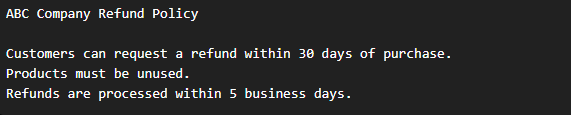

A normal LLM doesnt automatically has access to this document 

**RAG Solves this problem** 

## What is RAG?- 

RAG allows the LLM to retrieve this documenet first and then answer the question using the rertrieved information. 

RAG is technique that allows an LLM to search for relevant information from an external knowledge source before generating an answer 

Instead of depending only on what the AI learned during training, RAG gives the AI additional information at that time you ask the questiin 

Think of RAG as:

User Question → Search for relevant information → Give information to LLM → Generate Answer

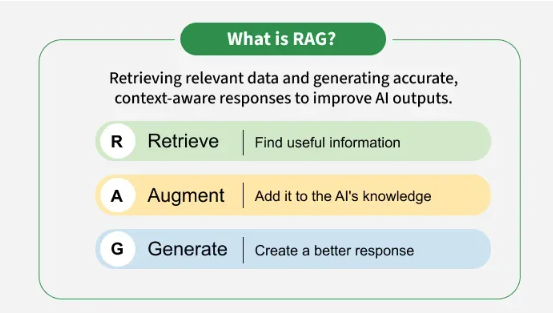

- Retrieval : The system searches your documents/ database/ Knowledge base. 
- Augumented : The retrieved information is given to LLM as additional context 
- Generation : The LLM uses tge question + retrieved information to produce the response. 

-------------

**Example**

Imagine you upload three documents to a RAG system:

Document 1:
ABC University's Admission Policy

Document 2:
ABC University's Tuition Policy

Document 3:
ABC University's Scholarship Policy

You ask: "What is the scholarship amount for internatal students?

The RAG system doesnt need to read all three documen to every time. Instead, it searches for information related to:

"scholarship amount international students"

It may retrive this section:

Scholarship Policy:

International students can receive scholarships
up to $10,000 per academic year.

Then the system gives the retrived information to LLM

The LLM receives something conceptually like:

Question:
What is the scholarship amount for international students?

Relevant Context:
International students can receive scholarships
up to $10,000 per academic year.

Then LLM generates "International students can receive scholarships of up to $10,000 per academic year."

That **RAG**



## Why do we need RAG ?

**Problem 1 : LLM may not know private information**

Suppose a univeristy has:

- student handbook
- Course catalog 
- Tuition  Polices 
- Scholarship policies 
- Academic calendar 

You can build a RAG system that allows students to ask:

"How many credit do I need to graduate?"

The system searches the university documents and gives the relevant information to the LLM 

--------

**Problem 2: Information can Change**

Suppose a company changes its refund policy. 

Old informatio: Refund within 30 days. 

New information: Refund withing 60 days.

You don't need necessarily need to retrain the entire LLM 

You can update the external knowledge base used by RAG system, RAG keeps the models weights unchanged while allowing the information it uses to be updated 

----------

**Probelem 3: Hallucination**

An LLM can sometime produce an answer that sound correct but isnt. This is called hallucination. 

RAG reduces this problem by giving the LLM relevant source information to use when generating the answer. 

How, remember:

RAG reduce hallucination; it does not completely eliminate them. 

if the retrieval system find the wrong information, the LLM can still produce a wrong answer. 

------

**Problem 4: LLMs have limited Context**

Suppose you has 500 page employee handbook:

You ask : What is the maternity leave policy?

You don't want to give the entire 500-page document to the LLM every time. 

That would be : 500 page document - LLM - very large amount of information. Instead RAG searches the document 

It might find only:
Page 127 
Section 8.2 

Employee are eligible for .....

Then only the relevant information is given to LLM 

500-page document- Search - Relevant Section - LLM - Answer 

This makes the process more efficient. 

---------

**Problem 5: You Don't Want to Retrain the LLM Every Time Information Changes**

Suppose you have LLM trained on the information about your company 

Then your company adds: 100 new documents 

You could theoretically retrain/fine- a tune a model but that can be unnecessary, expensive and cumbersone. 

With RAG:

New Documents - Process Documents - Create embeddings - Store in vector database - Available for retrieval 

You can update the knowledge base instead of changing the underlying model 

----------
**Problem 6: LLM Doesnt Automatically Know Your Database**

Imagine an e-commerce company has a database:
Customer | Products | Orders | Reviews | Inventory 

A customer asks: " Is iphone 17 pro currently in stock?"

A normal LLM doesn't automatically have access to the company live inventory database 

RAG or related reterival/based achitecture can connect the language model to external information 

The sytem can retrives 

Product : iphone 17 pro , Stock 24 units 

Then LLM Respond : "Yes there are currently 24 units in stock."This is particularly useful when answers depend on information outside the model itself.

-------
*Other Problem**
- Searching by Keywords Isn't Enough: RAG uses semantic search and embeddings to find information based on meaning, even when the exact keywords are different.
- Large Amounts of Information: RAG searches a large knowledge base and retrieves only the most relevant chunks, instead of sending all documents to the LLM.
- RAG Makes Answers More Grounded: RAG provides the LLM with relevant information from trusted sources, helping it generate more accurate and context-based answers.
- RAG Can Provide Sources/Citations: RAG can keep track of the documents or passages used for retrieval, allowing the system to show where the answer came from.

----------

**Why not just put the entrie documents in prompt?**
 
You might ask:

"Why do we need retrival? Why cant we just give entire document to ChatGPT?"

But there are several problems:

- Documents may be huge 
- More tokens can mean higher computational cost 
- Irrelevant information 

RAG tried to retrive the relevant pieces. 

-----------

**Why not just fine tune with LLM?**

Suppose we have: Company policy and you want LLM to know it

Now: let find tune the model using the policy. But companies policies can change 

For example: 

January: Vaccation = 15 days 

June: Vacation = 20 days 

If the policy is stored in a knowledge base, you can update the document.

With fine-tuning, changing the model's learned behavior/knowledge can require another training process.

So for frequently changing factual information, RAG is often a better fit.


### How RAG architecture works

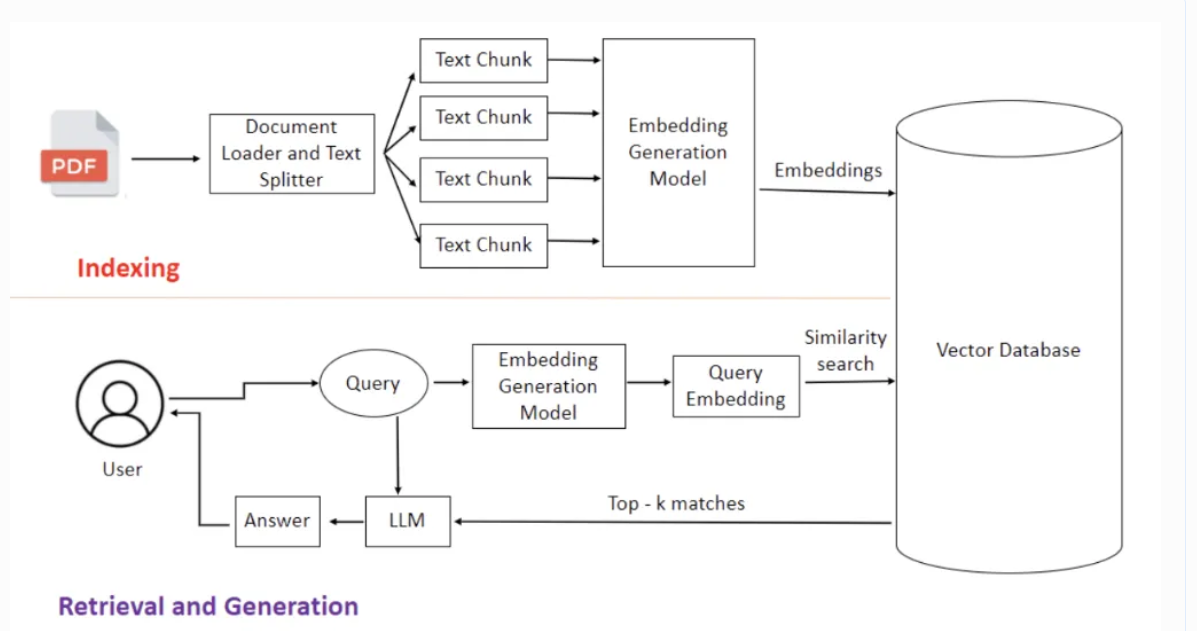


RAG is divided into two main phases. 

**Phase 1: Indexing (done ahead of time, offline)**

This is the "preparation" phase — building the knowledge base the system will search later.

- **Document Ingestion & Chunking** — Raw documents (PDFs, wikis, manuals) get split into smaller pieces. This matters because embedding models and LLM context windows have size limits, and smaller, well-scoped chunks retrieve more precisely.
- **Embedding Generation** — Each chunk is passed through an embedding model, producing a dense vector that captures its semantic meaning.
- **Vector Storage** — These vectors are stored in a vector database (e.g., Pinecone, Weaviate, FAISS, pgvector), often alongside metadata (source, date, section) for filtering later.

**Phase 2: Query Time (done live, per user request)**

This is what happens the moment a user asks something.

- **Query Embedding** — The user's question is embedded using the same embedding model used for the documents, so they're in the same "meaning space" and comparable.
- **Similarity Search / Retrieval** — The system compares the query vector against stored document vectors (commonly using cosine similarity or dot product) and returns the top-k most relevant chunks.
- **Re-ranking (optional but common in production systems)** — A secondary, more precise model re-scores the retrieved chunks, since fast vector search can be a blunt instrument. This step trades a bit of speed for better relevance.
- **Prompt Construction (Augmentation)** — The retrieved chunks are inserted into a prompt template along with the user's original question and system instructions.
- **Generation** — The LLM reads this augmented prompt and produces the final answer, ideally grounded in the retrieved text rather than pure memory.


#### **Chunking Technique**

**Most important steps of RAG**

Suppose documents might be very large 

For example: Students_Handsout.pdf - 600 pages 

We don't want to give the entire 300-page document to the LLM every time a user asks a question.

So we divide the document into smaller pieces called chunks.

Documents - Chunk 1| Chunk 2| Chunk 3| Chunk 4| Chunk 5.....

**Chunk is a smaller section of documents that contains a meaningful piece of information**

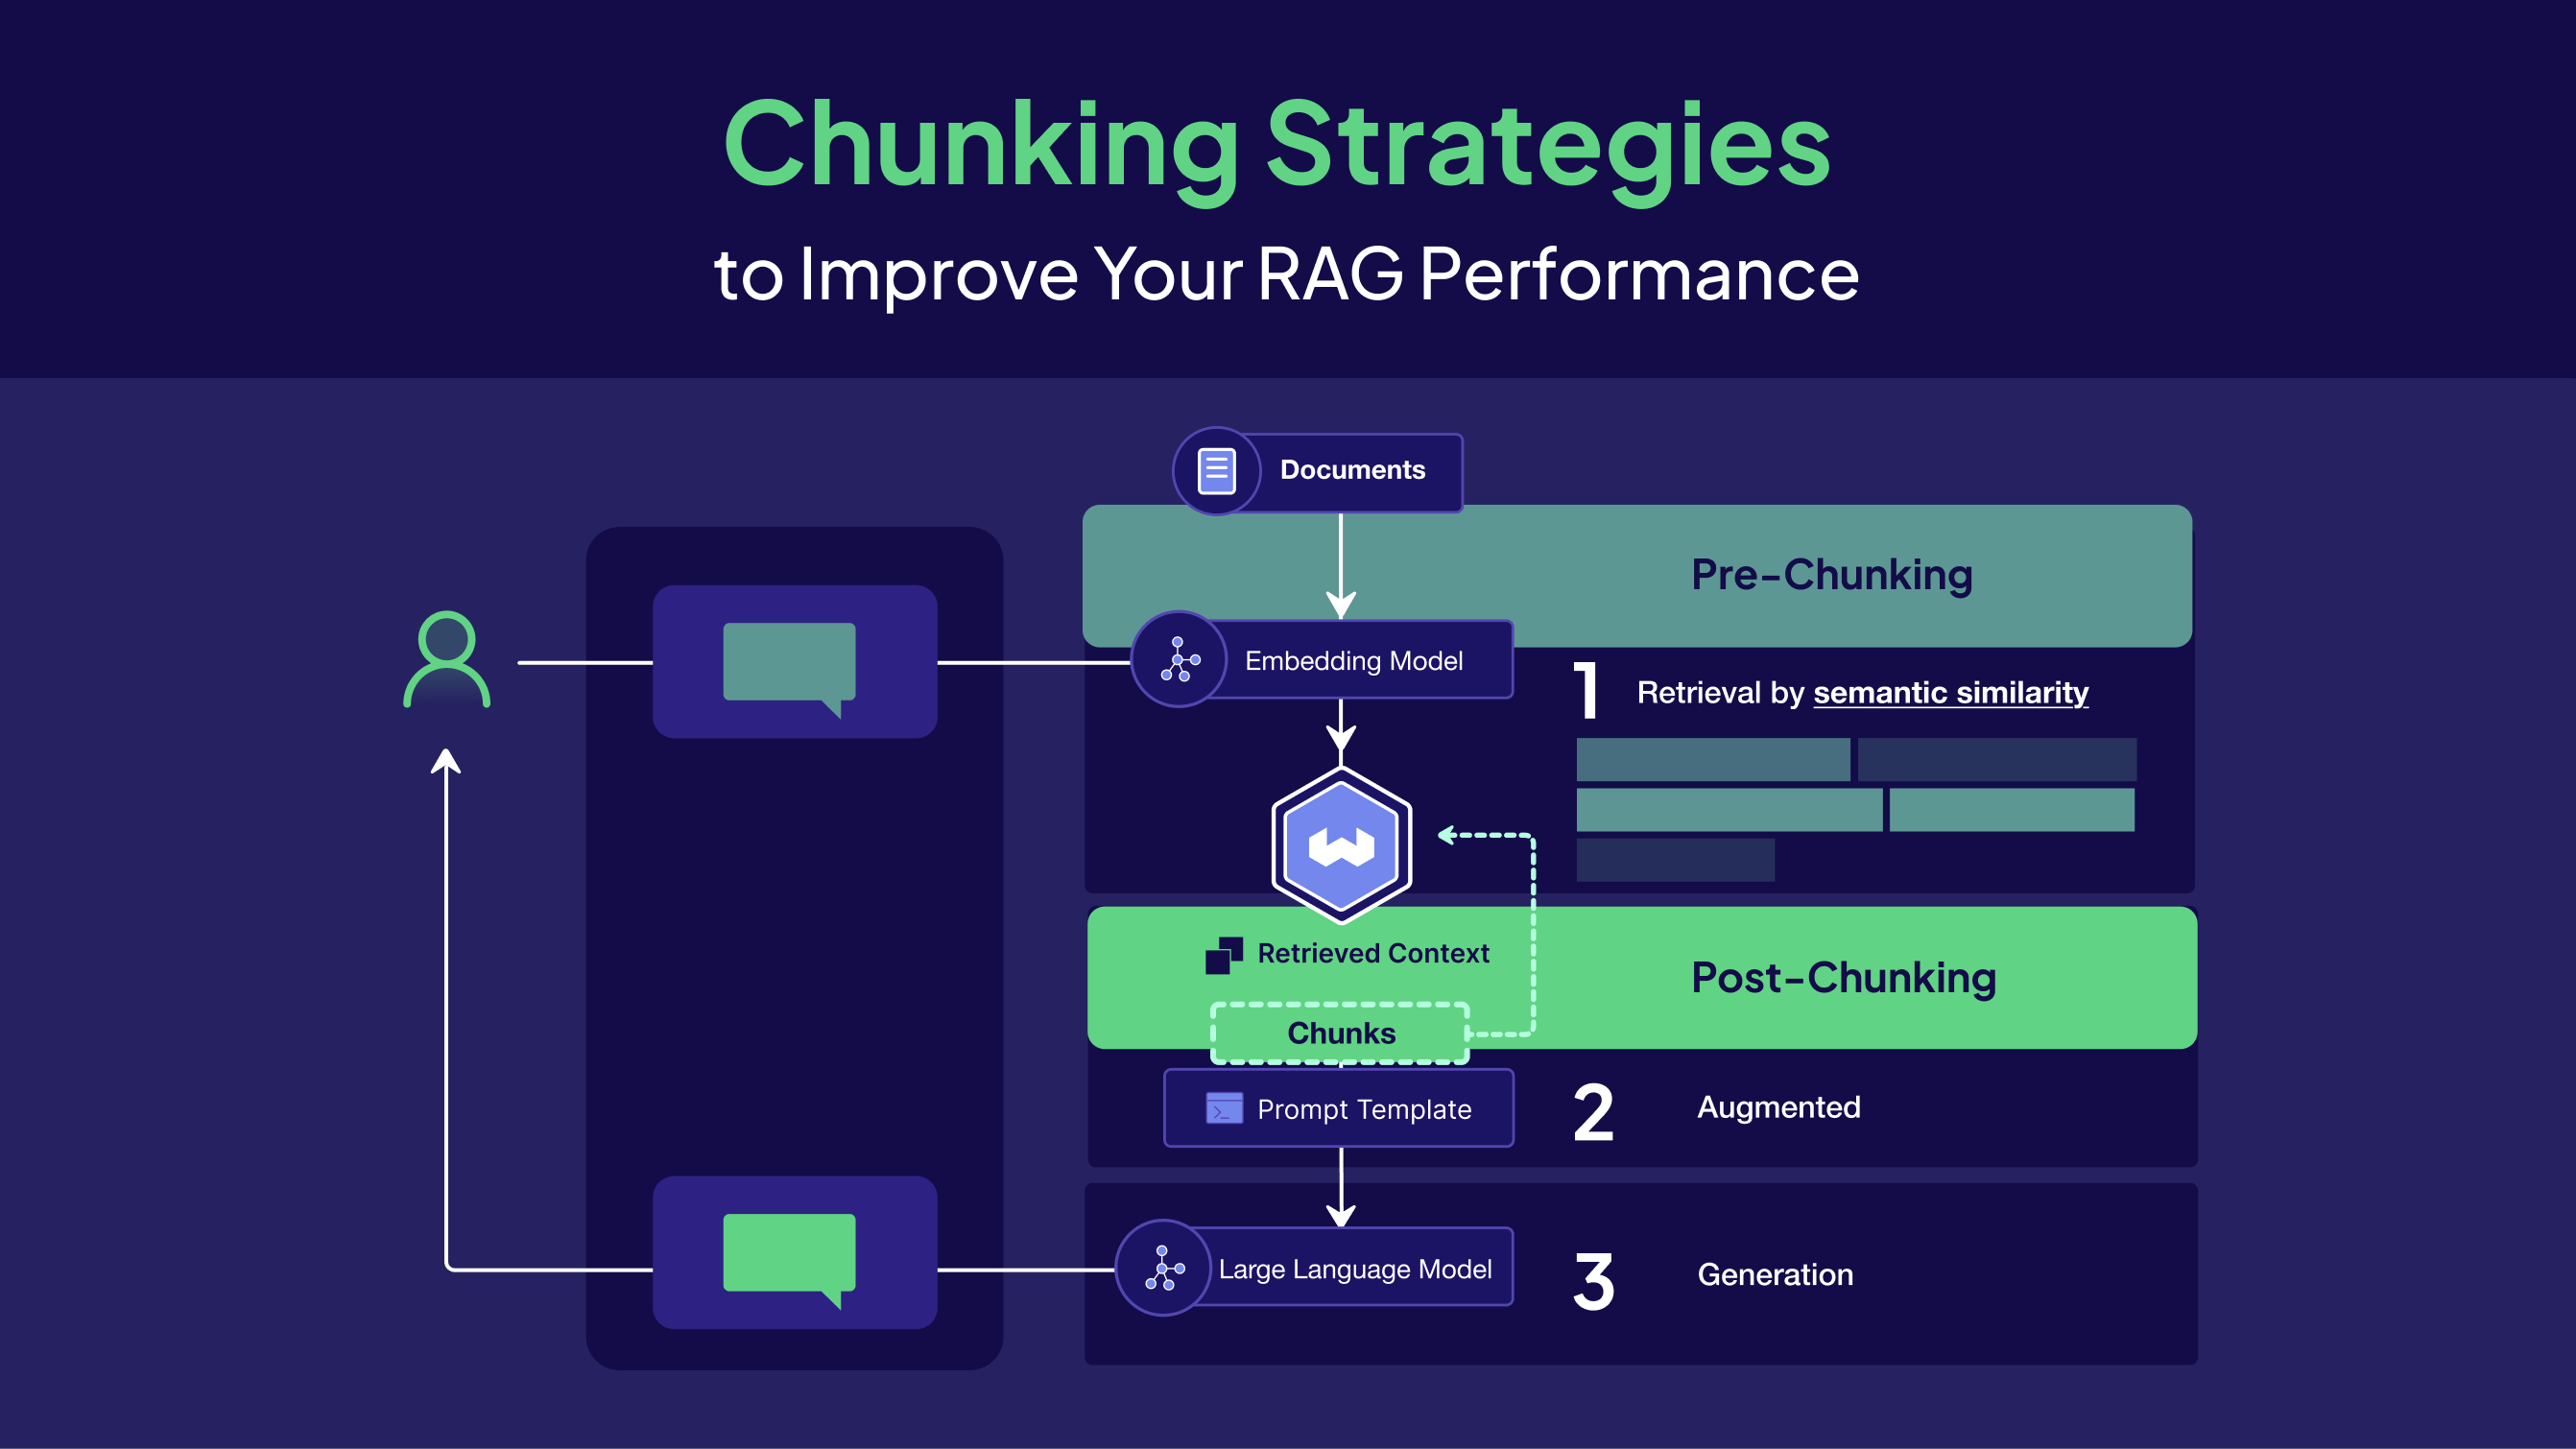

The size, content, and semantic boundaries of each chunk influence retrieval performance, and so deciding which technique to use can have a huge downstream impact on your RAG system’s performance.

----------

##### Why Chunking is important in RAG ?

Chunking is important because it decides how documents are divided before they are converted into embeddings and stored in a vector database.

- Better Retrieval: Small, focused chunks represent one clear idea, making it easier for vector search to find relevant information.
- Preserves Context: Chunks should be large enough to contain the complete meaning of an idea so the LLM can understand it.
- Reduces Hallucinations: Relevant and well-formed chunks give the LLM factual context, reducing made-up answers.
- Controls Context Size: Good chunking prevents sending unnecessary information to the LLM, avoiding context overload.
- Improves Efficiency: Smaller, relevant chunks reduce processing time and LLM costs.


**The goal is to find the sweet spot: chunks should be small enough for accurate search but large enough to preserve meaning and context.**

Generally 200-800 tokens is sweet spot but there is no definition depends upon what kinds of document you are dealing with 

----------
##### Pre- Chunking and Post Chunking 

The main difference is when the documnet is divided into chunks. 

1. **<u>Pre Chunking</u>**

Chunk first → Embed → Store → Retrieve

Before user ask questions, the documents is already divided into smaller chunks 

Example:

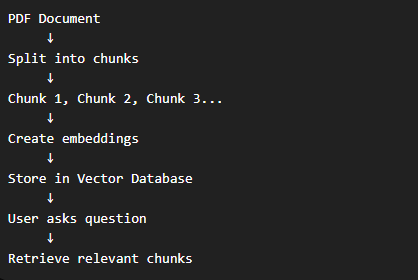

**Advantages:**

- Fast retrieval 
- Simple Architecture 
- Chunks are already prepared 
- Good for large document collections 

**Disadvantages**: You must decide the chunk size and boundaries in advance. A poorly choosen chunking strategy can hurt retrieval quality. 

2. **<u>Post-Chunking</u>**

Embed document first → Retrieve document → Chunk only when needed

Instead of creating chunks beforehand, the system intially stores the whole document. When a user ask a question, it first retrives the relevant document and then divided that document into chunks 

Example:

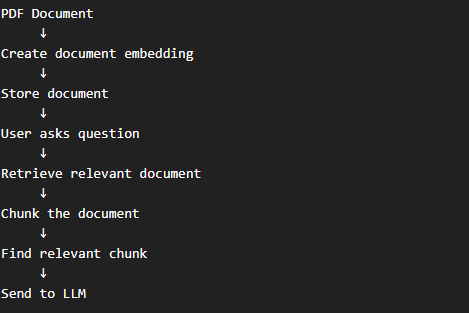

**Advantages**

- Documents that are never queried dont need to be chunked. 
- Chunking can be very specific and more dynamic 
- Frequently used chunks can be cached for faster future queries 

**Disadvantages** 

- First query can be slower because chunking happens at query time.
- More complex system design is required.




#### Chunking Strategies 

Chunking stratgey depends upond the type of documents that you are working with and needs of RAG application. 

1. **Fixed Size Chunking (or Token Chunking)**

It divided a document into chunks with a predicted number of tokens or chracters 

For example: if the chunk size is 50 tokens, the document is split every 50 tokens 

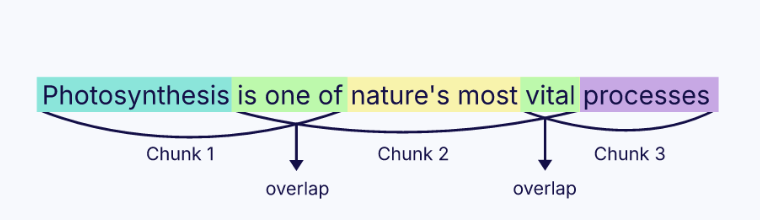

**Chunk Overlap**- Sometimes an important idea is split between two chunks. To avoid losing this context, we use overlap.

**Important Parameters**

- Chunk Size: Determines how much text goes into each chunk.Smaller → more precise retrieval | Larger → more context
- Chunk Overlap: Repeats some content between chunks to preserve context.
- Easy to Implement: Makes it a good starting strategy for RAG.

**When to use** 

- You are building quick RAG prototype 
- Documents dont have a consistent structure 
- You need a simple baseline to compare other chunking methods 

------------------------

2. **Reccursive Chunking**

It divides text using the hierarchy of sperators, instead of simple cutting the text after a fixed number of characters or tokens. 

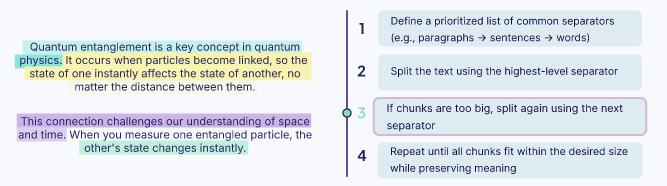

**How it works**

- Start with largest structure : Paragraphs - Sentence - Words
- First, split by paragraphs. If paragraoph is already small enough, keep it one chunk. 
- If a paragraph is too large, split it into sentence. 
- if a sentence is still to large, split it further into smaller units. 

**It is called recursive because it repeats the splitting process on chunks that are still too large.**

**Why is it useful for RAG?** 

- Preserves context better than fixed-size chunking.
- Avoids cutting sentences randomly.
- Keeps related information together.
- Works well with articles, blogs, research papers, and other text documents.
- It is a good default strategy for many RAG applications.

--------

3. **Documents Based Chunking**

Document based chunking splits a document according to its natural structure instead of using generic separators. 

- Markdown: Split by headings like # and ##.
- HTML: Split by HTML tags
- PDF: Split using headings, paragraphs, tables, etc., after processing.
- Code: Split by functions or classes.

**Why to use it**: It keeps each chunk as a meaningful logical unit, which improves retrieval and understanding in RAG systems.

**When to Use**: Best for highly structured documents such as Markdown, HTML, PDFs, JSON, and source code.

------------

4. **Sematic Chunking**

Semantic chunking is a technique used to divide a document into chunks based on meaning, rather than simply splitting after a fixed number of characters, words, or paragraphs.

Main idea: If neighboring sentences have similar meanings, keep them together. If their meaning becomes significantly different, create a new chunk.

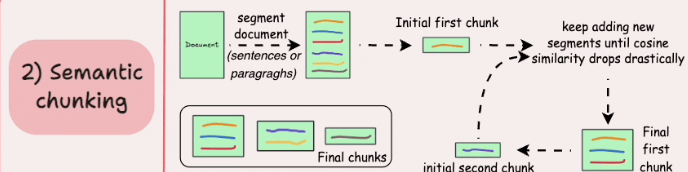

**<u>Steps for Segmatic Chunking</u>**

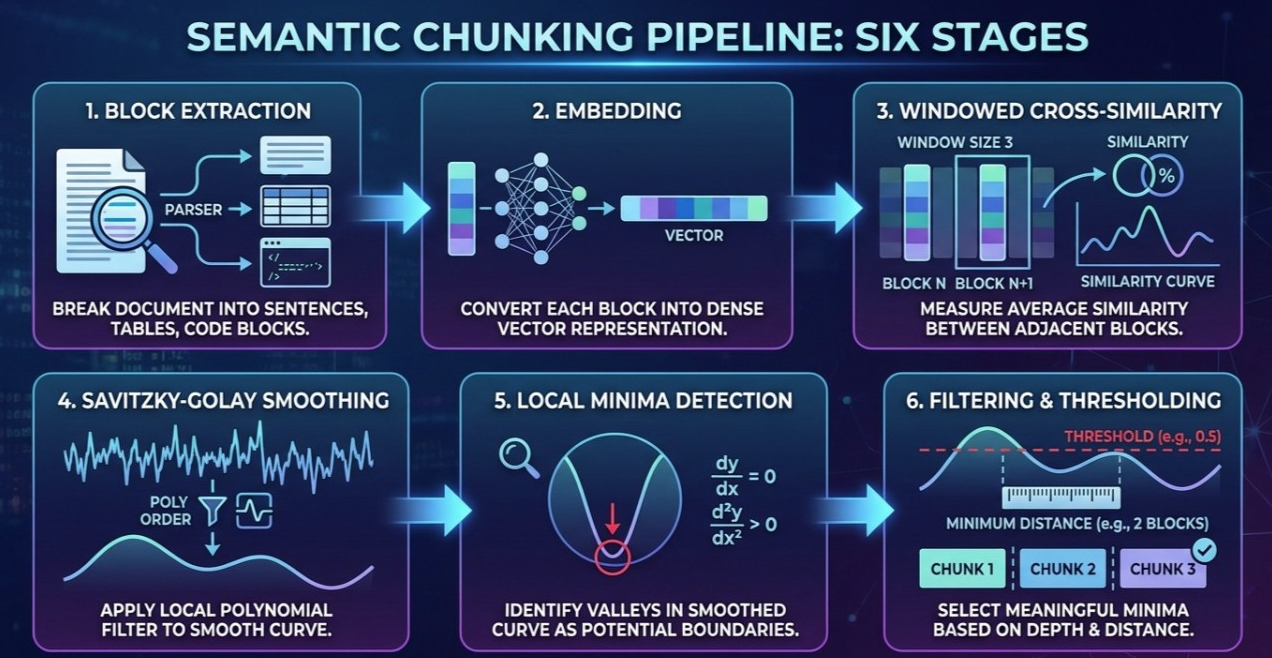

**Step 1: Block Extraction**

Break the document into small meaningful units, usually sentences. Structural elements such as tables and code blocks can be kept as units.

**Step 2 Embedding** 

Convert each block into an embedding vector that represents its meaning.

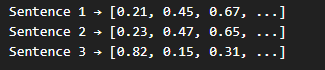

Similar sentences have a similar vectors

**Step 3 Similarity Analysis**

Compare neighboring embeddings, usually using cosine similarity.(Cosine Similarity  measures how close two vectors are finding the cosine of the angle between them)

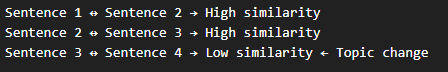

A drop is similarity indicates a possible semantic boundary 

**Step 4 Smoothing**

The similarity signal can cintain small random fluctations. Techniqie such as **windowed averging** and **Savitzky Golay filter** smooth the signal so that genuine topic changes are easier to detect

(Windowed Averging:  method that calculates the average of a fixed number of consecutive data points (the "window") and moves that window forward one step at a time as new data arrives.)

(Savitzky Golay filter: It works by moving a window across data points and fitting a low-degree polynomial to the points inside that window using linear least squares)

**Step 5 Find Local Minima**

After smoothing, the system looks for valleys(low points) in the similarity curve. 

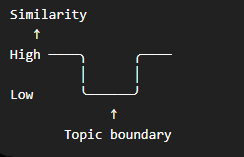

A deep valley usually means the topic chnaged significantly 

**Step 6 Filtering & Thresolding**

Not every small dip is a real topic change. The system filters the detected boundaries using:

- Threshold: Determines how significant the topic change must be.
- Minimum distance: Prevents chunks from becoming too small.

Segmatic Chunking is useful in RAG beacuse it helps to create coherent, self contianed chunks, making it more likely the vector database retrives the complete information needed to asnwer a user question. 

--------------------------

5. LLM Based Chunking

LLM-based chunking uses a Large Language Model (LLM) to understand the text and decide where and how to split it.

Instead of simply looking at characters, paragraphs, or embedding similarity, the LLM actually analyzes the meaning and context of the document.

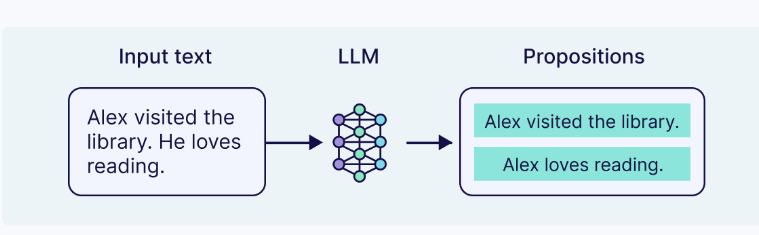

**How it works**

1. Read the document: The LLM processes the text and understands its context.
2. Identify logical ideas: It finds where one idea or topic ends and another begins.
3. Create meaningful chunks: Related information is grouped together.
4. Add context if needed: The LLM can also create summaries, key points, or additional context for each chunk.

**Advantages:** Highly accurate and context-aware.

**Disadvantages:** More expensive and slower than other chunking methods.

When to use: Best for complex, high-value documents such as legal contracts, research papers, compliance documents, and enterprise knowledge bases.

---------------

6. **Agnetic Chunking**

Agentic Chunking is an advanced chunking technique where an AI agent decided how to split document instead of following one fixed chunking rule. 

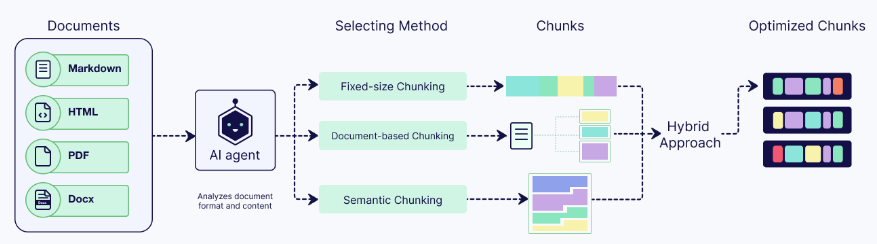

**How it works**

Suppose you give three documents to agents:

- Document 1- Markdown documentation 
- Document 2 - Research Paper 
- Document 3 - Legal Contract 

The agent doest use the same method for all three 

It might decide 

- Markdown - Splits by heading 
- Research Paper - Semantic chunking 
- Legal contract- LLM based/ proposition chunking 

It can even combine multiple methods for one document. 

**Advantages:**  Flexible, intelligent, and high-quality chunks.
**Disadvantages:**  More expensive and computationally intensive.

**When to use**: Best for high stakes RAG systems which retrieval quality is more important than cost

----------------------
7. Late Chunking 

Late Chunking is technique designed to reduce context loss during chunking. 

**How it works**

- Normal Chunking: Split document → Create embeddings
- Late chunking:Create embeddings for the whole document → Split into chunks

The entire document is first processed by a long-context embedding model, so each token's embedding contains information about the surrounding document. Then the document is divided into chunks, and the relevant token embeddings are combined to create the chunk embedding.

Create embeddings for the whole document → Split into chunks

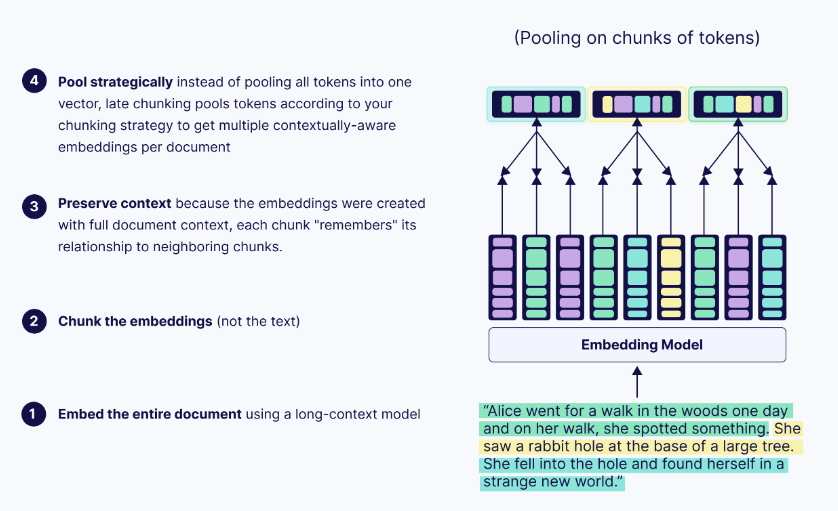

Late chunking is especially useful for RAG with documents where sections depend on information mentioned elsewhere, such as:

- Research papers
- Technical documentation
- Legal documents
- Long reports

Main Benefit: Each chunks embedding retain context from the larger documents, improving retrieval quality

-------

8. Hierachical Chunking 

Hierarchical chunking divides a large document into multiple levels of chunks, from broad information to detailed information.

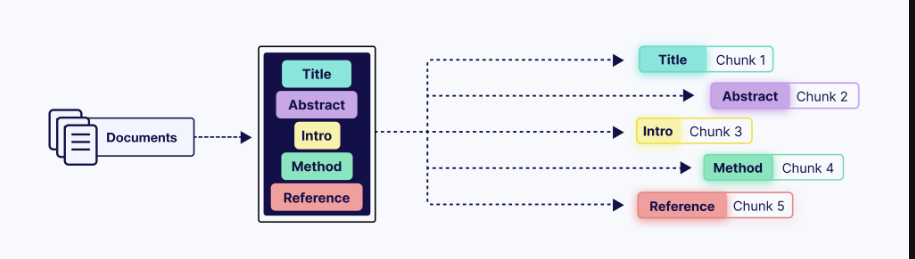

**How it works**

Document - Large Selection - Smaller selection - Detailed chunk 

For example, a textbook might be divided into:

- Level 1: Chapter → broad topic
- Level 2: Section → specific topic
- Level 3: Paragraph → detailed information

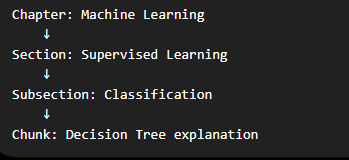

This allows a RAG system to first find the relevant broad section and then retrieve the specific detailed chunk.

**Why to use it**

- Preserves both high-level and detailed context
- Improves retrieval for different types of questions
- Useful for very large documents

When to use :Best for textbooks, legal documents, research papers, and technical manuals.

-------

9. **Adaptive Chunking**

Adaptive chunking automatically changes the chunk size and overlap based on the content of the document.

Instead of using one fixed chunk size everywhere, it creates:

- Smaller chunks → for dense, complex, information-rich text.
- Larger chunks → for simple or general sections.

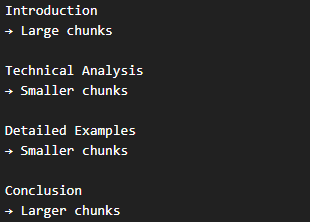

**Why use it** : It avoids the one-size-fits-all problem and creates chunks that better match the content, improving retrieval accuracy and context.

**When to Use**: Best for documents with different levels of complexity, such as long reports, technical documents, and mixed-content documents.

------

**How to choose the best chunking strategy**

There is no single best chunking method. The right choice depends on your data, RAG requirements, and query complexity.

1. Do I need chunking?

First, check whether your data is already small and meaningful.

- What is the nature of my documents? Are they highly structured (like code or JSON), or are they unstructured narrative text?
- What level of detail does my RAG system need? Does it need to retrieve specific, granular facts or summarize broader concepts?
- Which embedding model am I using? What are the size of the output vectors (more dimensions increases the ability for more granular information to be stored)??
- How complex will my user queries be? Will they be simple questions that need small, targeted chunks, or complex ones that require more context?

| Chunking Strategy | How It Works | Complexity | Best For | Examples |
|---|---|---|---|---|
| Fixed-Size (or Token) | Splits by token or character count. | Low | Small or simple docs, or when speed matters most | Meeting notes, short blog posts, emails, simple FAQs |
| Recursive | Splits text by repeatedly dividing it until it fits the desired chunk size, often preserving some structure. | Medium | Documents where some structure should be maintained but speed is still important | Research articles, product guides, short reports |
| Document-Based | Treats each document as a single chunk or splits only at document boundaries. | Low | Collections of short, standalone documents | News articles, customer support tickets, short contracts |
| Semantic | Splits text at natural meaning boundaries (topics, ideas). | Medium-High | Technical, academic, or narrative documents | Scientific papers, textbooks, novels, whitepapers |
| LLM-Based | Uses a language model to decide chunk boundaries based on context, meaning, or task needs. | High | Complex text where meaning-aware chunking improves downstream tasks like summarization or Q&A | Long reports, legal opinions, medical records |
| Agentic | Lets an AI agent decide how to split based on meaning and structure. | Very High | Complex, nuanced documents that require custom strategies | Regulatory filings, multi-section contracts, corporate policies |
| Late | Embeds the whole document first, then derives chunk embeddings from it. | High | Use cases where chunks need awareness of full document context | Case studies, comprehensive manuals, long-form analysis reports |
| Hierarchical | Breaks text into multiple levels (sections → paragraphs → sentences). Keeps structure intact. | Medium | Large, structured docs like manuals, reports, or contracts | Employee handbooks, government regulations, software documentation |
| Adaptive | Adjusts chunk size and overlap dynamically with ML or heuristics. | High | Mixed datasets with varying structures and lengths | Data from multiple sources: blogs, PDFs, emails, technical docs |
| Code | Splits by logical code blocks (functions, classes, modules) while preserving syntax. | Medium | Source code, scripts, or programming documentation | Python modules, JavaScript projects, API docs, Jupyter notebooks |

-----------

**Library for Chunking**

- LangChain: A broad framework for building LLM applications. Its flexible TextSplitters make it easy to integrate chunking as part of a larger system, like a multi-step AI agent. Best for: modular workflows where chunking is just one piece of the puzzle.
- LlamaIndex: Designed specifically for RAG pipelines. Its sophisticated NodeParsers produce “Nodes,” optimized for ingestion and retrieval.Best for: high-performance, data-centric retrieval systems.
- chonkie: A lightweight, dedicated chunking library that focuses solely on splitting text. It offers a variety of chunking strategies such as SemanticChunker and is easy to integrate with other RAG libraries.
Best for: projects where you want a simple, focused solution without the overhead of a larger framework.

---------

Important topic to be remebered 

**Retrieval Recall**

It measures how well a retrieval system finds all the relevant documents/chunks from a collection.

**Why is Retrieval Recall important in RAG?**

A RAG system can only generate a good answer if it retrieves the right information.

High recall → More relevant information is retrieved → lower chance of missing important information.
Low recall → Important information may be missed → the LLM may give an incomplete or incorrect answer.

**MRR- Means Reciprocal Rank**

MRR (Mean Reciprocal Rank) is a metric used to evaluate how high the first relevant result appears in a search or retrieval system.

**In RAG, MRR helps answer:**

“How quickly does the retriever find the first relevant chunk?”

**Why MRR is useful for RAG**
MRR evaluates whether relevant chunks are ranked near the top.

MRR = 1.0 → The first relevant chunk is always ranked 1st.
Higher MRR → Relevant chunks generally appear higher.
Lower MRR → Relevant chunks tend to appear lower.



### Vector Embeddings

First let's understand what is Embeddings 

**Embeddings**: Think of it like this, computer dont understand words - they understand numbers, so we need a way to turn words sentence or paragraphs into numbers without loosing their meaning. 

An embedding is just that: a list of numbers that represents the meaning of a piece of text.

**Why do we need Embedding**

Computers are very good at working with numbers.

Once text is converted into vectors, we can perform mathematical operations such as:

- Calculate similarity
- Find related information
- Search large amounts of data
- Group similar information
- Retrieve relevant documents
- Compare sentences

-------------------------------------------------------------

**Vector Embedding**

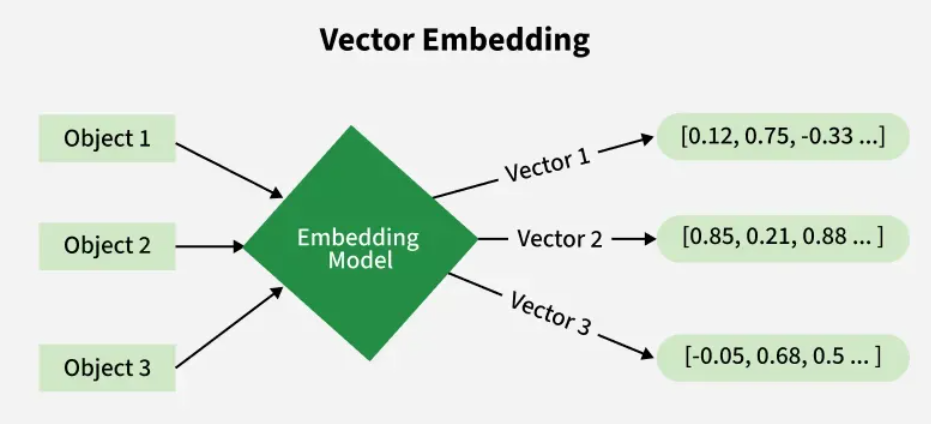

Vector Embedding is a technique used to convert data such as text, sentences, documents, images, or other information into a numerical representation called a vector.

In RAG we mainly use text embeddings. A text embedding represents the semantic meaning and relationships of text as a list of numbers.

**Why do we convert text into vectors**

Human naturally understand that these sentence are related 

"I want to reset my password."

"How can I change my login credentials?"

A computer however needs a mathematical represntation to efficiently compare them 

Therefore we convert them into vectors 

The vectors can then be mathematically compared.

If they are close in the embedding space, the system considers them semantically similar.

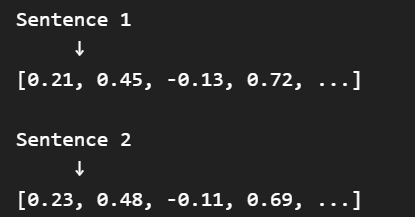

**What does the vector represents**

The vector represents the overall semantic characteristics of the text.

For example: The vector represents the overall semantic characteristics of the text.  and "Apple released a new iPhone." | Use different word but their meaning are related

Their embeddings should be relatively close in embedding space

Conceptually 

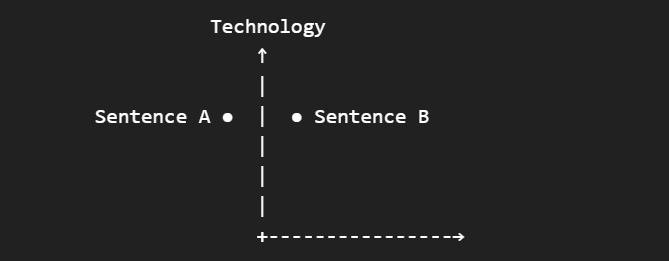

The closer two embeddings are, generally, the more semantically related the corresponding texts are.

**Use of Vector Embedding**

- Compare Similarities: Measures vector distances to identify semantically similar data.
- Clustering: Groups related data using algorithms like K-means or DBSCAN.
- Perform Arithmetic Operations: Captures relationships and analogies through vector math.
- Feed Machine Understandable Data: Converts complex data into vectors for machine processing.

------------------------------------------------------

**How does the computer know which vectors are similar**

After converting text into vectors, we need a mathematical method to compare them.

This is called similarity measurement.

One common method is cosine similarity. (Cosine similarity  measures how close two vectors are by finding the cosine of the angle between them)

Conceptually :

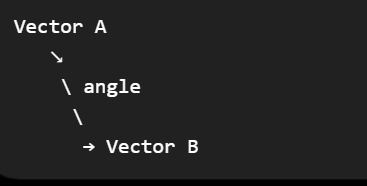

If two vectors point in similar directions, their cosine similarity is high.

-----------------------------------------

#### Types of Vector Embedding 

1. **Word Embedding**

Word Embeddings converts an individual word into a vector 

Each word is transformed into numeric vectors and similar words have closer vector representations allowing models to understand relationship between them.

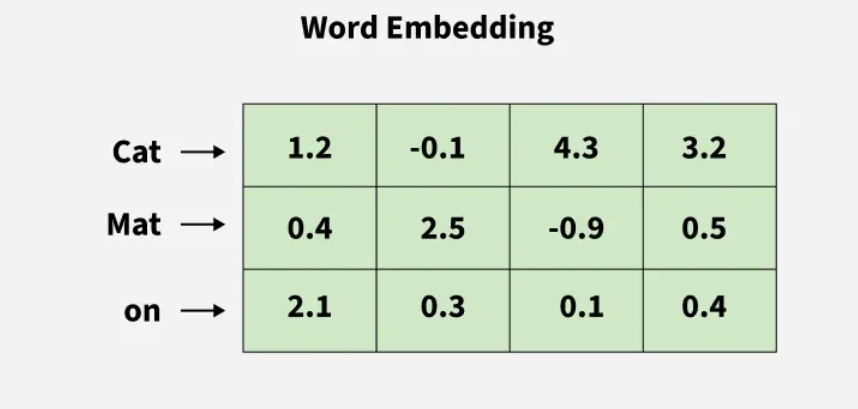

Words with related meanings can have similar vectors. 

Example- Word2vec , GloVe, FastText

2. **Sentence Embedding**

A sentence embedding converts an entire sentence into one vector.It aims at finding the semantic meaning of entire phrases or sentences rather than individual words. They are generated with SBERT or other variants of sentence transformers.

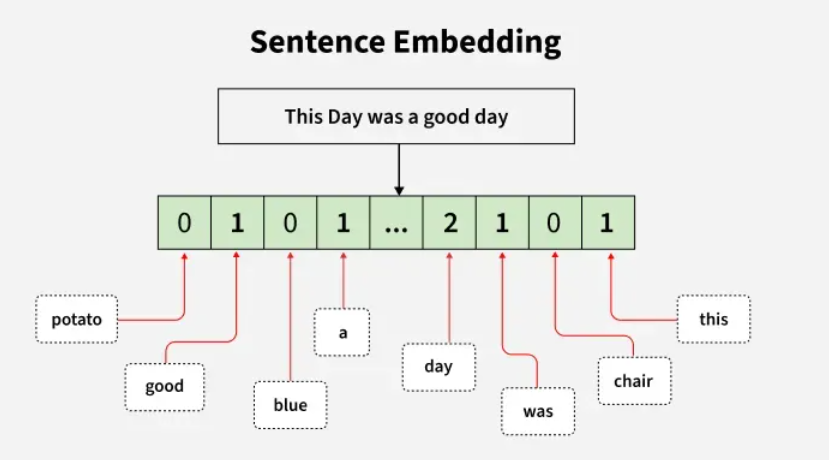

Each word of the sentence is transformed into numeric vectors and zero is imparted to words which are not present in the sentence.

3. **Document / Chunk Embedding**

Document or chunk embedding represents a paragraph or a smaller section of a document as a vector.

Example:

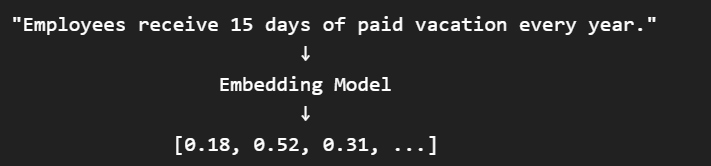

This is very important in RAG.

In RAG, large documents are divided into smaller chunks, and each chunk is converted into an embedding and stored in a vector database.

Use: Semantic search and retrieving relevant information from documents.

4. **Query Embedding**

Query embedding represents the user's question or search query as a vector.

Example :

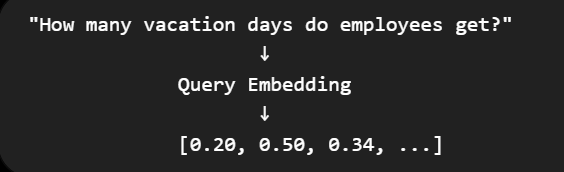

The query vector is compared with document/chunk vectors to find the most relevant information.

Use: Query retrieval in RAG and semantic search.

5. **Contextual Embedding**

Contextual embedding represents text based on the context in which it appears.

For example, the word "bank" has different meanings:

**"I deposited money in the bank."**

Here, bank means a financial institution

**"We sat beside the bank of the river."**

Here, bank means the side of a river.

A contextual embedding considers the surrounding words to understand the correct meaning.

Use: Understanding the meaning of words based on their context.

6. **Multimodal Embedding**

Multimodal embedding represents different types of data, such as:

- Text
- Images
- Audio
- Video

as numerical vectors.

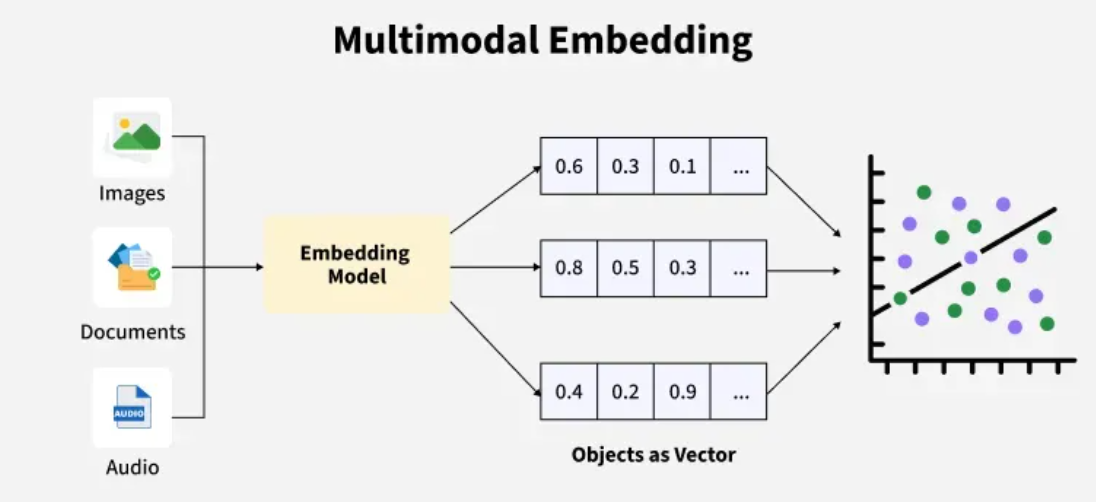

The text and image can have related vector representations.

Use: Image search, cross-modal search, and multimodal RAG.



